# Matrix-Free GP with ImplicitKernelOperator

For large $N$, forming the $N \times N$ kernel matrix $K$ requires
$O(N^2)$ memory and $O(N^3)$ time for dense factorizations.
`ImplicitKernelOperator` avoids materializing $K$ entirely: it computes
$K v$ on-the-fly by evaluating the kernel function row-by-row, using
only $O(N)$ memory. Combined with CG-based solvers, this enables GP
inference on problems that are too large for dense methods.

**What you'll learn:**

1. Building a matrix-free kernel operator with `ImplicitKernelOperator`
2. Solving kernel systems with `CGSolver`, `PreconditionedCGSolver`,
   and `BBMMSolver`
3. Using structural tags for metadata
4. Exploiting SVD structure with `SVDLowRankUpdate`
5. Full GP prediction: implicit vs dense

## 1. Setup

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

# Register missing lineax dispatches for ImplicitKernelOperator so
# that lineax CG (used internally by gaussx strategies) can work.
lx.is_negative_semidefinite.register(gaussx.ImplicitKernelOperator)(lambda _: False)
lx.linearise.register(gaussx.ImplicitKernelOperator)(lambda op: op)
lx.is_negative_semidefinite.register(gaussx.SVDLowRankUpdate)(lambda _: False)
lx.linearise.register(gaussx.SVDLowRankUpdate)(lambda op: op)

<function __main__.<lambda>(op)>

We generate a 1D GP regression problem with $N = 2000$ noisy
observations of a smooth function.

In [2]:
key = jax.random.PRNGKey(42)
N = 2000

# Training data: noisy sine
key_x, key_noise = jax.random.split(key)
X_train = jnp.sort(jax.random.uniform(key_x, (N, 1), minval=-5.0, maxval=5.0), axis=0)
f_true = jnp.sin(X_train[:, 0]) + 0.2 * jnp.cos(3.0 * X_train[:, 0])
noise_var = 0.1
y_train = f_true + jnp.sqrt(noise_var) * jax.random.normal(key_noise, (N,))

print(f"Training set: N = {N}, D = {X_train.shape[1]}")
print(f"Noise variance: {noise_var}")

Training set: N = 2000, D = 1
Noise variance: 0.1


## 2. Build ImplicitKernelOperator

We define a scalar RBF kernel

$$k(x, x') = \sigma_f^2 \exp\!\left(-\frac{\|x - x'\|^2}{2 \ell^2}\right)$$

where $x, x'$ are 1D arrays of shape `(D,)`. The kernel function is
passed to `ImplicitKernelOperator`, which wraps it into a lineax
operator that computes $(K + \sigma_n^2 I) v$ without ever forming $K$.

In [3]:
# Kernel hyperparameters
length_scale = 1.0
signal_var = 1.0


def rbf_kernel(x: jnp.ndarray, xp: jnp.ndarray) -> jnp.ndarray:
    """Scalar RBF kernel: k(x, x') -> scalar."""
    sq_dist = jnp.sum((x - xp) ** 2)
    return signal_var * jnp.exp(-0.5 * sq_dist / length_scale**2)


op = gaussx.ImplicitKernelOperator(
    rbf_kernel,
    X_train,
    noise_var=noise_var,
    tags=frozenset({lx.positive_semidefinite_tag, lx.symmetric_tag}),
)
print(f"Operator size: {op.in_size()} x {op.out_size()}")

Operator size: 2000 x 2000


The operator supports `mv` (matrix-vector product) for CG-based
methods. It also has `as_matrix()` for debugging, but that
materializes the full $N \times N$ matrix -- exactly what we want to
avoid at scale.

In [4]:
# Verify matvec matches dense
v = jax.random.normal(jax.random.PRNGKey(0), (N,))

mv_implicit = op.mv(v)

# Dense reference (expensive -- only for validation)
K_dense = op.as_matrix()
mv_dense = K_dense @ v

err = jnp.max(jnp.abs(mv_implicit - mv_dense))
print(f"Matvec error (implicit vs dense): {err:.2e}")

Matvec error (implicit vs dense): 5.68e-14


## 3. Solve with CGSolver

`CGSolver` uses lineax CG for the linear solve $(K + \sigma_n^2 I)
\alpha = y$ and matfree's stochastic Lanczos quadrature (SLQ) for the
log-determinant. It only needs matvec access -- no matrix
materialization.

In [5]:
cg = gaussx.CGSolver(rtol=1e-6, atol=1e-6, max_steps=200, num_probes=30)

alpha_cg = cg.solve(op, y_train)

residual_cg = jnp.max(jnp.abs(op.mv(alpha_cg) - y_train))
print(f"CG solve residual: {residual_cg:.2e}")

CG solve residual: 9.80e-07


In [6]:
logdet_cg = cg.logdet(op, key=jax.random.PRNGKey(0))
print(f"CG stochastic logdet: {logdet_cg:.4f}")

# Dense reference logdet
logdet_dense = jnp.linalg.slogdet(K_dense)[1]
print(f"Dense logdet:         {logdet_dense:.4f}")
print(f"Logdet error:         {jnp.abs(logdet_cg - logdet_dense):.2e}")

CG stochastic logdet: -4522.7308


Dense logdet:         -4522.1695
Logdet error:         5.61e-01


## 4. Solve with PreconditionedCGSolver

`PreconditionedCGSolver` builds a rank-$k$ partial Cholesky
preconditioner that dramatically reduces the number of CG iterations
for ill-conditioned kernel systems. The `shift` parameter should match
the noise variance.

In [7]:
pcg = gaussx.PreconditionedCGSolver(
    preconditioner_rank=30,
    shift=noise_var,
    rtol=1e-6,
    atol=1e-6,
)

alpha_pcg = pcg.solve(op, y_train)

residual_pcg = jnp.max(jnp.abs(op.mv(alpha_pcg) - y_train))
print(f"Preconditioned CG solve residual: {residual_pcg:.2e}")

# Compare with plain CG
diff_pcg_cg = jnp.max(jnp.abs(alpha_pcg - alpha_cg))
print(f"Max |alpha_pcg - alpha_cg|:       {diff_pcg_cg:.2e}")

Preconditioned CG solve residual: 9.76e-08
Max |alpha_pcg - alpha_cg|:       2.02e-06


## 5. Solve with BBMMSolver

`BBMMSolver` (Gardner et al. 2018) jointly computes the solve and
log-determinant via `solve_and_logdet`, amortizing the matvec cost.

In [8]:
bbmm = gaussx.BBMMSolver(
    cg_max_iter=200,
    cg_tolerance=1e-6,
    lanczos_iter=50,
    num_probes=20,
)

alpha_bbmm, ld_bbmm = bbmm.solve_and_logdet(op, y_train)

residual_bbmm = jnp.max(jnp.abs(op.mv(alpha_bbmm) - y_train))
print(f"BBMM solve residual: {residual_bbmm:.2e}")
print(f"BBMM logdet:         {ld_bbmm:.4f}")
print(f"Dense logdet:        {logdet_dense:.4f}")

BBMM solve residual: 9.80e-07
BBMM logdet:         -4527.8656
Dense logdet:        -4522.1695


### Solver comparison

All three iterative solvers converge to the same solution.

In [9]:
print("Max difference between solvers:")
print(f"  CG   vs PCG:  {jnp.max(jnp.abs(alpha_cg - alpha_pcg)):.2e}")
print(f"  CG   vs BBMM: {jnp.max(jnp.abs(alpha_cg - alpha_bbmm)):.2e}")
print(f"  PCG  vs BBMM: {jnp.max(jnp.abs(alpha_pcg - alpha_bbmm)):.2e}")

Max difference between solvers:
  CG   vs PCG:  2.02e-06
  CG   vs BBMM: 0.00e+00
  PCG  vs BBMM: 2.02e-06


## 6. Tags for structural metadata

`ImplicitKernelOperator` accepts lineax tags to declare structural
properties. Kernel matrices from stationary kernels are symmetric
and positive semi-definite; declaring this lets lineax and gaussx
exploit the structure.

In [10]:
op_tagged = gaussx.ImplicitKernelOperator(
    rbf_kernel,
    X_train,
    noise_var=noise_var,
    tags=frozenset({lx.symmetric_tag, lx.positive_semidefinite_tag}),
)

print(f"is_symmetric:              {gaussx.is_symmetric(op_tagged)}")
print(f"is_positive_semidefinite:  {gaussx.is_positive_semidefinite(op_tagged)}")

is_symmetric:              True
is_positive_semidefinite:  True


## 7. SVDLowRankUpdate

When a truncated SVD approximation of the kernel matrix is available
(e.g., from a Nystrom approximation), `SVDLowRankUpdate` represents
the operator as $L + U \operatorname{diag}(S) V^\top$ and exploits
the SVD structure for efficient solves and log-determinants.

Here we compute a dense truncated SVD for demonstration. In practice,
you would obtain $U, S, V$ from a randomized or Nystrom method
without forming the full matrix.

In [11]:
rank = 50

# Truncated SVD of the kernel matrix (dense, for demonstration only)
K_no_noise = K_dense - noise_var * jnp.eye(N)
U_full, S_full, Vt_full = jnp.linalg.svd(K_no_noise, full_matrices=False)

U_k = U_full[:, :rank]
S_k = S_full[:rank]
V_k = Vt_full[:rank, :].T  # (N, rank)

# Base operator: noise_var * I
base_diag = lx.DiagonalLinearOperator(noise_var * jnp.ones(N))

svd_op = gaussx.SVDLowRankUpdate(
    base_diag,
    U_k,
    S_k,
    V_k,
    tags=frozenset({lx.positive_semidefinite_tag, lx.symmetric_tag}),
)
print(f"SVDLowRankUpdate: rank-{rank} approximation")
print(f"Operator size: {svd_op.in_size()} x {svd_op.out_size()}")

SVDLowRankUpdate: rank-50 approximation
Operator size: 2000 x 2000


In [12]:
# Solve with the SVD low-rank operator via CG
alpha_svd = cg.solve(svd_op, y_train)

residual_svd = jnp.max(jnp.abs(svd_op.mv(alpha_svd) - y_train))
print(f"SVD solve residual: {residual_svd:.2e}")

# Logdet via SLQ
logdet_svd = cg.logdet(svd_op, key=jax.random.PRNGKey(1))
print(f"SVD logdet:   {logdet_svd:.4f}")
print(f"Dense logdet: {logdet_dense:.4f}")

SVD solve residual: 1.05e-06


SVD logdet:   -4528.3541
Dense logdet: -4522.1695


## 8. GP prediction

With $\alpha = (K + \sigma_n^2 I)^{-1} y$ in hand, the posterior mean
at test points $X_*$ is

$$\mu_* = K_{*f} \, \alpha$$

We compare predictions from the implicit (CG) solve with the dense
Cholesky baseline.

In [13]:
# Test points
X_test = jnp.linspace(-5.5, 5.5, 300)[:, None]

# Cross-covariance: K(X_test, X_train) via vmap
K_star = jax.vmap(
    lambda x_star: jax.vmap(lambda x_tr: rbf_kernel(x_star, x_tr))(X_train)
)(X_test)

# Predictions from implicit CG solve
mu_cg = K_star @ alpha_cg

# Dense baseline
alpha_dense = jnp.linalg.solve(K_dense, y_train)
mu_dense = K_star @ alpha_dense

pred_err = jnp.max(jnp.abs(mu_cg - mu_dense))
print(f"Max prediction error (CG vs dense): {pred_err:.2e}")

Max prediction error (CG vs dense): 8.86e-07


## 9. Plot: implicit vs dense GP predictions

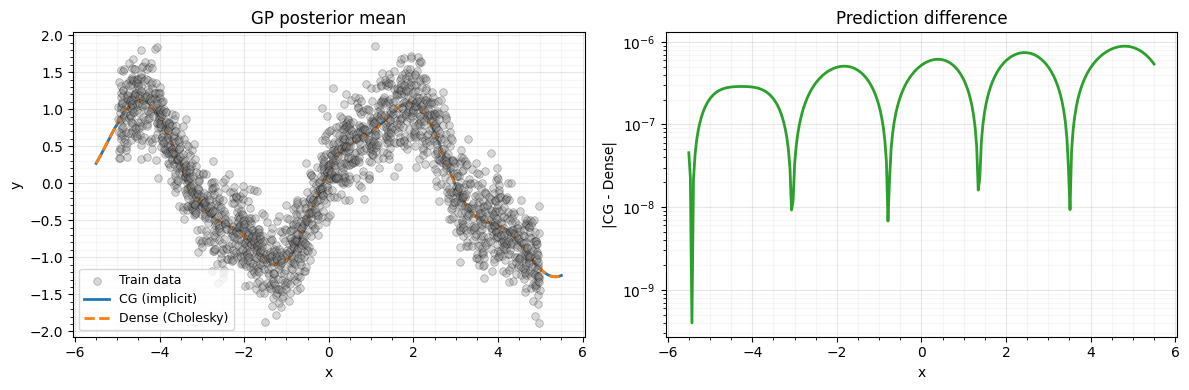

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: predictions
ax = axes[0]
ax.scatter(
    X_train[:, 0],
    y_train,
    s=30,
    alpha=0.3,
    color="gray",
    edgecolors="k",
    linewidths=0.5,
    label="Train data",
    zorder=5,
)
ax.plot(X_test[:, 0], mu_cg, color="C0", lw=2, label="CG (implicit)", zorder=3)
ax.plot(
    X_test[:, 0],
    mu_dense,
    "--",
    color="C1",
    lw=2,
    label="Dense (Cholesky)",
    zorder=3,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("GP posterior mean")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

# Right: absolute difference
ax = axes[1]
ax.plot(X_test[:, 0], jnp.abs(mu_cg - mu_dense), color="C2", lw=2)
ax.set_xlabel("x")
ax.set_ylabel("|CG - Dense|")
ax.set_title("Prediction difference")
ax.set_yscale("log")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

plt.tight_layout()
plt.show()

## Summary

- **`ImplicitKernelOperator`** -- Matrix-free $(K + \sigma^2 I) v$
  via on-the-fly kernel evaluation. $O(N)$ memory.
- **`CGSolver`** -- Iterative CG solve + SLQ logdet. Only needs
  matvec access.
- **`PreconditionedCGSolver`** -- Partial Cholesky preconditioner
  for faster CG convergence.
- **`BBMMSolver`** -- Joint solve + logdet via batched CG
  (Gardner et al. 2018).
- **`SVDLowRankUpdate`** -- SVD-parameterized low-rank structure
  for cheap solves and logdets.

**When to use what:**

- **Small $N$ ($< 5000$):** Dense Cholesky is fastest and exact.
- **Medium $N$ ($5000$--$50000$):** `CGSolver` or
  `PreconditionedCGSolver` with `ImplicitKernelOperator`.
- **Large $N$ ($> 50000$):** `BBMMSolver` with
  `ImplicitKernelOperator` amortizes matvec costs across solve and
  logdet. Use `PreconditionedCGSolver` if the system is
  ill-conditioned.
- **Low-rank structure available:** `SVDLowRankUpdate` exploits the
  factored form directly.